## Import libraries

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

## Analysis of noise_sampling_log.csv

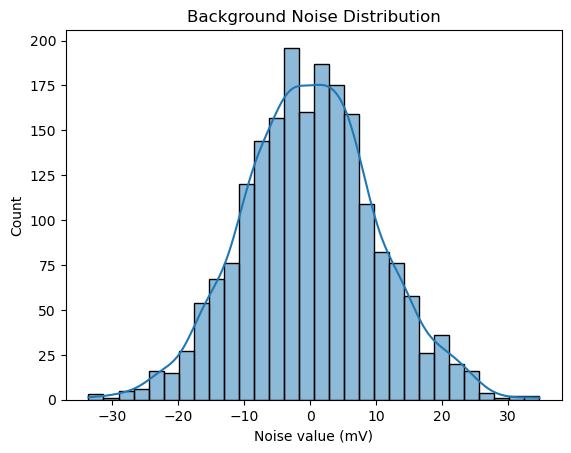

Number of datapoints: 2000
Mean: -0.018470788500000026
Standard deviation: 10.109140886812382

Shapiro-Wilk test:
Statistic = 0.9990047987869604
p-value = 0.33662932439919346


,time,noise_value
1,0.1,0.00000
3,0.2,5.06856
5,0.3,-11.53430
7,0.4,-4.46098
9,0.5,-3.11718


In [3]:
# load file
df_raw = pd.read_csv("../bin/noise_sampling_log.csv", sep=";", skiprows=1)

# keep only rows corresponding to the output messages
df_noise = df_raw[df_raw["port_name"] == "noise_out"].copy()

# keep only relevant columns
df_noise = df_noise[["time", "data"]]

# ensure numeric type
df_noise["data"] = pd.to_numeric(df_noise["data"], errors="coerce")

# rename column for clarity
df_noise = df_noise.rename(columns={"data": "noise_value"})

# basic statistics
n = len(df_noise)
mean_val = df_noise["noise_value"].mean()
std_val = df_noise["noise_value"].std()

# Shapiro–Wilk normality test
shapiro_stat, shapiro_p = shapiro(df_noise["noise_value"])

sns.histplot(df_noise["noise_value"], bins=30, kde=True)
plt.xlabel("Noise value (mV)")
plt.title("Background Noise Distribution")
#plt.savefig("noise_qqplot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Number of datapoints:", n)
print("Mean:", mean_val)
print("Standard deviation:", std_val)
print("\nShapiro-Wilk test:")
print("Statistic =", shapiro_stat)
print("p-value =", shapiro_p)

df_noise.head()

## Analysis of neuron_always_fire_log.csv

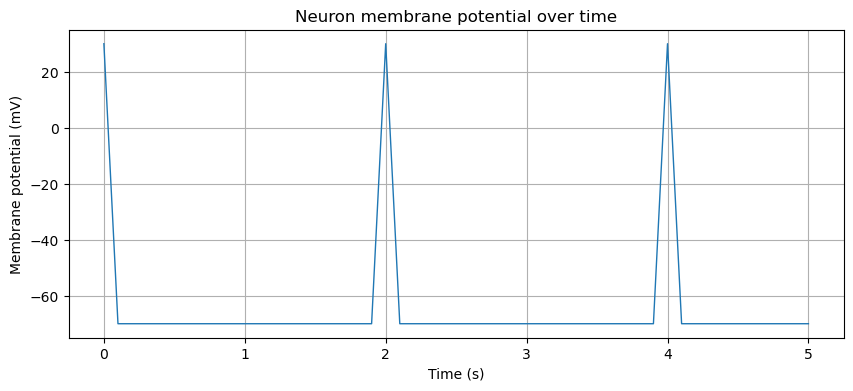

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Load file
df = pd.read_csv("../bin/neuron_always_fire_log.csv", sep=";", skiprows=1)

# Keep only state rows (port_name empty)
df_state = df[df["port_name"].isna() | (df["port_name"] == "")].copy()

# Extract membrane potential V from the data column
df_state["V"] = df_state["data"].str.extract(r"V:\s*(-?\d+\.?\d*)").astype(float)

# Convert time to numeric
df_state["time"] = df_state["time"].astype(float)

# Plot
plt.figure(figsize=(10,4))
plt.plot(df_state["time"], df_state["V"], linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (mV)")
plt.title("Neuron membrane potential over time")
plt.grid(True)

# Save figure
#plt.savefig("neuron_always_fire_voltage.png", dpi=300, bbox_inches="tight")

plt.show()

## Analysis of neuron_never_fire_log.csv

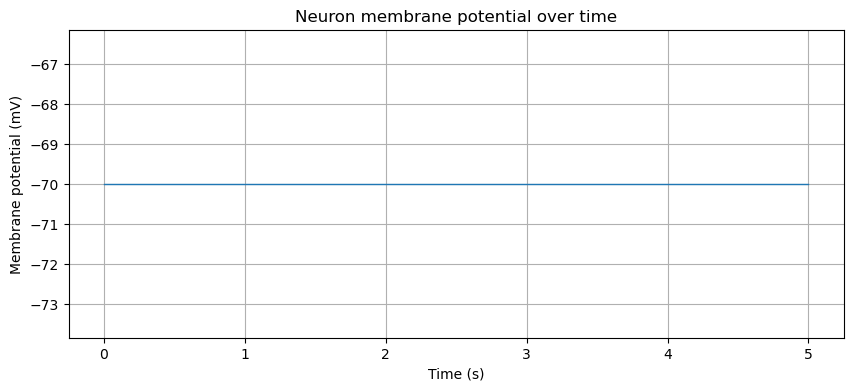

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Load file
df = pd.read_csv("../bin/neuron_never_fire_log.csv", sep=";", skiprows=1)

# Keep only state rows (port_name empty)
df_state = df[df["port_name"].isna() | (df["port_name"] == "")].copy()

# Extract membrane potential V from the data column
df_state["V"] = df_state["data"].str.extract(r"V:\s*(-?\d+\.?\d*)").astype(float)

# Convert time to numeric
df_state["time"] = df_state["time"].astype(float)

# Plot
plt.figure(figsize=(10,4))
plt.plot(df_state["time"], df_state["V"], linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (mV)")
plt.title("Neuron membrane potential over time")
plt.grid(True)

# Save figure
#plt.savefig("neuron_never_fire_voltage.png", dpi=300, bbox_inches="tight")

plt.show()

## Analysis of neuron_default_log.csv

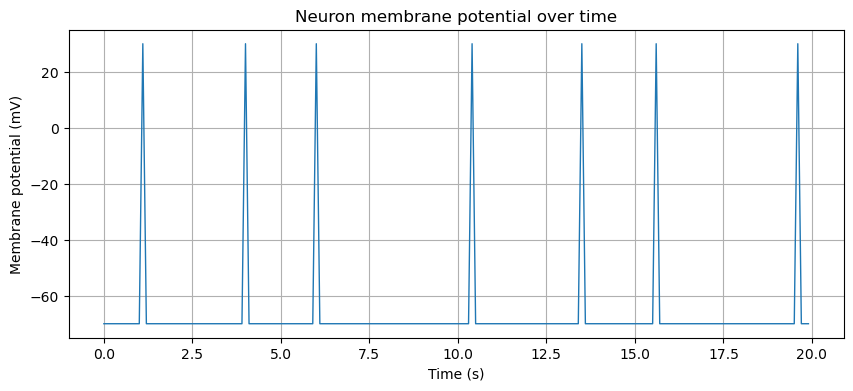

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Load file
df = pd.read_csv("../bin/neuron_default_log.csv", sep=";", skiprows=1)

# Keep only state rows (port_name empty)
df_state = df[df["port_name"].isna() | (df["port_name"] == "")].copy()

# Extract membrane potential V from the data column
df_state["V"] = df_state["data"].str.extract(r"V:\s*(-?\d+\.?\d*)").astype(float)

# Convert time to numeric
df_state["time"] = df_state["time"].astype(float)

# Plot
plt.figure(figsize=(10,4))
plt.plot(df_state["time"], df_state["V"], linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (mV)")
plt.title("Neuron membrane potential over time")
plt.grid(True)

# Save figure
#plt.savefig("neuron_default_voltage.png", dpi=300, bbox_inches="tight")

plt.show()

## Analysis of adder_simple_log.csv

In [7]:
import pandas as pd

# Load CSV
df = pd.read_csv("../bin/adder_simple_log.csv", sep=";", skiprows=1)

# Convert time to numeric
df["time"] = df["time"].astype(float)

# --- Extract inputs ---

# neuron1 spikes
n1 = df[(df["model_name"]=="neuron1") & (df["port_name"]=="potential_out")][["time","data"]]
n1 = n1.rename(columns={"data":"n1"})
n1["n1"] = n1["n1"].astype(float)

# neuron2 spikes
n2 = df[(df["model_name"]=="neuron2") & (df["port_name"]=="potential_out")][["time","data"]]
n2 = n2.rename(columns={"data":"n2"})
n2["n2"] = n2["n2"].astype(float)

# noise
noise = df[(df["model_name"]=="noise") & (df["port_name"]=="noise_out")][["time","data"]]
noise = noise.rename(columns={"data":"noise"})
noise["noise"] = noise["noise"].astype(float)

# adder output
out = df[(df["model_name"]=="adder") & (df["port_name"]=="sum_out")][["time","data"]]
out = out.rename(columns={"data":"sum_out"})
out["sum_out"] = out["sum_out"].astype(float)

# --- Merge everything by time ---
merged = out.merge(noise, on="time", how="left") \
            .merge(n1, on="time", how="left") \
            .merge(n2, on="time", how="left")

# --- Compute expected sum ---
merged["expected_sum"] = (
    merged["noise"].fillna(0)
    + 0.9 * merged["n1"].fillna(0)
    + 0.75 * merged["n2"].fillna(0)
)

# --- Reorder columns ---
merged = merged[["time","noise","n1","n2","expected_sum","sum_out"]]

# Show first rows
merged.head(10)

,time,noise,n1,n2,expected_sum,sum_out
0,0.1,0.000000,NaN,NaN,0.000000,0.000000
1,0.2,-13.283500,30.0,NaN,13.716500,13.716500
2,0.3,-14.793400,NaN,NaN,-14.793400,-14.793400
3,0.4,-0.649843,NaN,NaN,-0.649843,-0.649843
4,0.5,0.639798,NaN,NaN,0.639798,0.639798
5,0.6,0.143151,NaN,NaN,0.143151,0.143151
6,0.7,7.962390,NaN,NaN,7.962390,7.962390
7,0.8,14.519400,NaN,30.0,37.019400,37.019400
8,0.9,10.594600,NaN,NaN,10.594600,10.594600
9,1.0,11.277300,NaN,NaN,11.277300,11.277300


## Analysis of electrode_threshold_crossing_log.csv

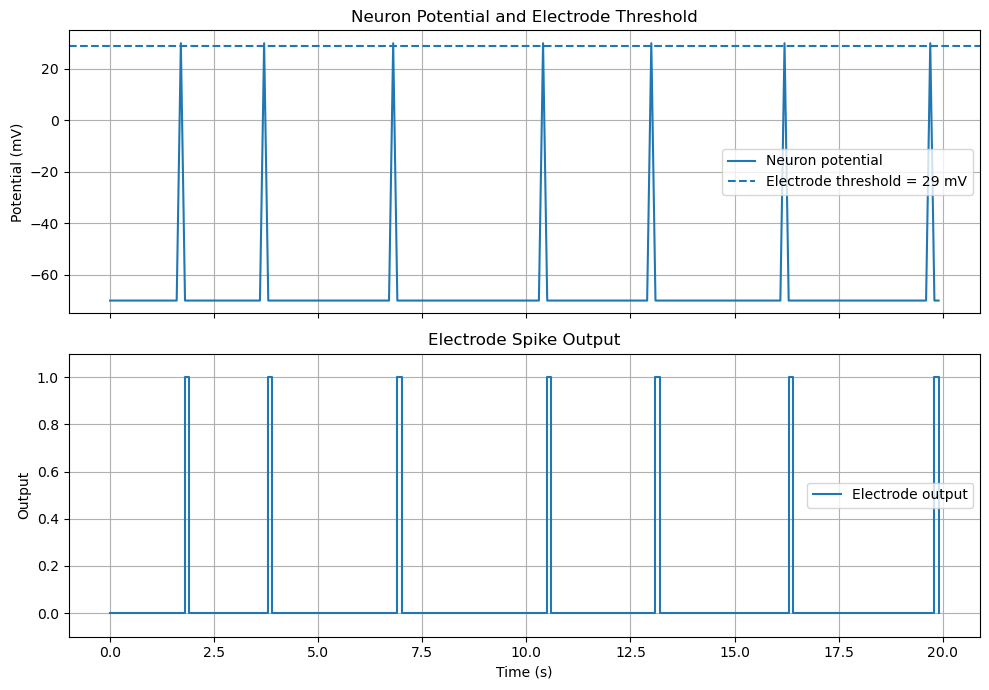

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load the log
# -----------------------------
df = pd.read_csv("../bin/electrode_threshold_crossing_log.csv", sep=";", skiprows=1)
df["time"] = df["time"].astype(float)

# -----------------------------
# Neuron state rows: extract V
# -----------------------------
df_neuron = df[
    (df["model_name"] == "neuron") &
    (df["port_name"].isna() | (df["port_name"] == ""))
].copy()

df_neuron["V"] = (
    df_neuron["data"]
    .str.extract(r"V:\s*(-?\d+\.?\d*)")[0]
    .astype(float)
)

# -----------------------------
# Electrode state rows: extract threshold
# -----------------------------
df_elec_state = df[
    (df["model_name"] == "electrode") &
    (df["port_name"].isna() | (df["port_name"] == ""))
].copy()

df_elec_state["threshold"] = (
    df_elec_state["data"]
    .str.extract(r"threshold:\s*(-?\d+\.?\d*)")[0]
    .astype(float)
)

# Use the first threshold value (constant in this experiment)
threshold = df_elec_state["threshold"].iloc[0]

# -----------------------------
# Electrode output rows
# -----------------------------
df_elec_out = df[
    (df["model_name"] == "electrode") &
    (df["port_name"] == "spike_out")
].copy()

df_elec_out["spike"] = pd.to_numeric(df_elec_out["data"], errors="coerce")

# Build a full time grid using neuron timestamps
df_plot_out = df_neuron[["time"]].copy()
df_plot_out = df_plot_out.merge(
    df_elec_out[["time", "spike"]],
    on="time",
    how="left"
)
df_plot_out["spike"] = df_plot_out["spike"].fillna(0)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top subplot: neuron potential
axes[0].plot(df_neuron["time"], df_neuron["V"], label="Neuron potential")
axes[0].axhline(
    y=threshold,
    linestyle="--",
    label=f"Electrode threshold = {threshold:.0f} mV"
)
axes[0].set_ylabel("Potential (mV)")
axes[0].set_title("Neuron Potential and Electrode Threshold")
axes[0].grid(True)
axes[0].legend()

# Bottom subplot: electrode outputs
axes[1].step(df_plot_out["time"], df_plot_out["spike"], where="post", label="Electrode output")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Output")
axes[1].set_title("Electrode Spike Output")
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
#plt.savefig("electrode_threshold_crossing_plots.png", dpi=300, bbox_inches="tight")
plt.show()

## Analysis of electrod_threshold_high_log.csv

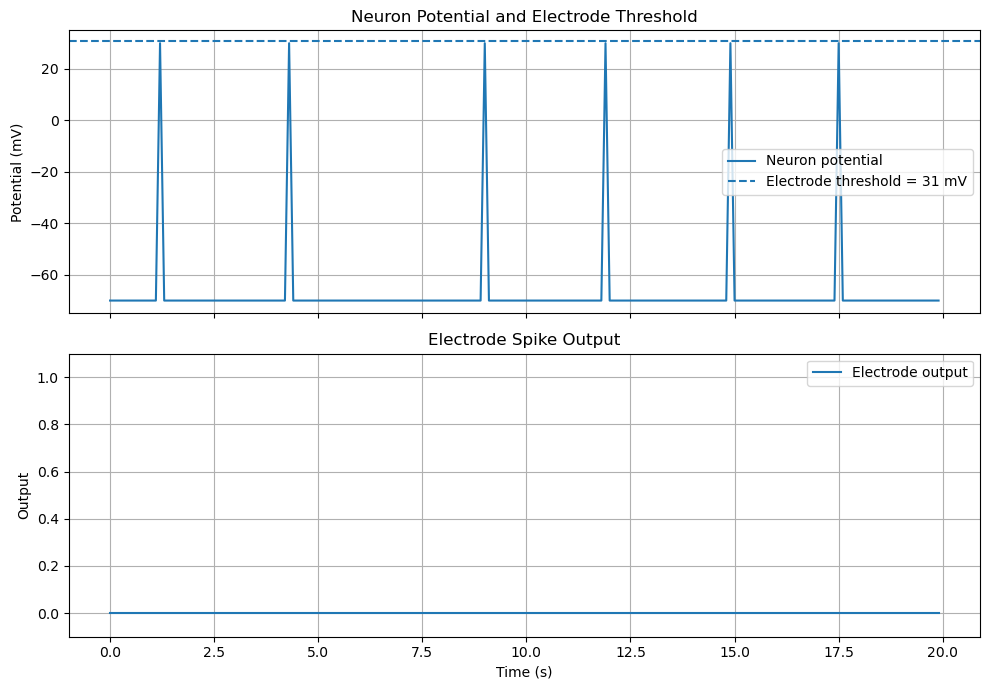

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load the log
# -----------------------------
df = pd.read_csv("../bin/electrode_high_threshold_log.csv", sep=";", skiprows=1)
df["time"] = df["time"].astype(float)

# -----------------------------
# Neuron state rows: extract V
# -----------------------------
df_neuron = df[
    (df["model_name"] == "neuron") &
    (df["port_name"].isna() | (df["port_name"] == ""))
].copy()

df_neuron["V"] = (
    df_neuron["data"]
    .str.extract(r"V:\s*(-?\d+\.?\d*)")[0]
    .astype(float)
)

# -----------------------------
# Electrode state rows: extract threshold
# -----------------------------
df_elec_state = df[
    (df["model_name"] == "electrode") &
    (df["port_name"].isna() | (df["port_name"] == ""))
].copy()

df_elec_state["threshold"] = (
    df_elec_state["data"]
    .str.extract(r"threshold:\s*(-?\d+\.?\d*)")[0]
    .astype(float)
)

# Use the first threshold value (constant in this experiment)
threshold = df_elec_state["threshold"].iloc[0]

# -----------------------------
# Electrode output rows
# -----------------------------
df_elec_out = df[
    (df["model_name"] == "electrode") &
    (df["port_name"] == "spike_out")
].copy()

df_elec_out["spike"] = pd.to_numeric(df_elec_out["data"], errors="coerce")

# Build a full time grid using neuron timestamps
df_plot_out = df_neuron[["time"]].copy()
df_plot_out = df_plot_out.merge(
    df_elec_out[["time", "spike"]],
    on="time",
    how="left"
)
df_plot_out["spike"] = df_plot_out["spike"].fillna(0)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top subplot: neuron potential
axes[0].plot(df_neuron["time"], df_neuron["V"], label="Neuron potential")
axes[0].axhline(
    y=threshold,
    linestyle="--",
    label=f"Electrode threshold = {threshold:.0f} mV"
)
axes[0].set_ylabel("Potential (mV)")
axes[0].set_title("Neuron Potential and Electrode Threshold")
axes[0].grid(True)
axes[0].legend()

# Bottom subplot: electrode outputs
axes[1].step(df_plot_out["time"], df_plot_out["spike"], where="post", label="Electrode output")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Output")
axes[1].set_title("Electrode Spike Output")
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
#plt.savefig("electrode_high_threshold_plots.png", dpi=300, bbox_inches="tight")
plt.show()

## Analysis of top_threshold_45_log.csv

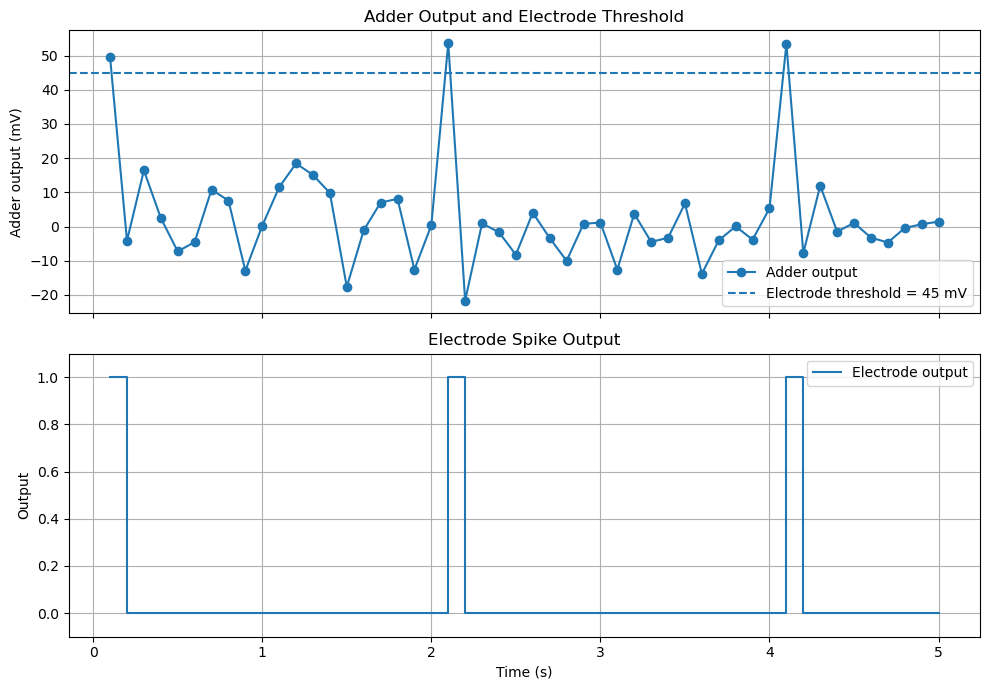

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load the log
# -----------------------------
df = pd.read_csv("../bin/top_threshold_45_log.csv", sep=";", skiprows=1)
df["time"] = df["time"].astype(float)

# -----------------------------
# Extract adder outputs
# -----------------------------
df_adder = df[
    (df["model_name"] == "adder") &
    (df["port_name"] == "sum_out")
].copy()

df_adder["sum_out"] = pd.to_numeric(df_adder["data"], errors="coerce")

# -----------------------------
# Extract electrode outputs
# -----------------------------
df_elec_out = df[
    (df["model_name"] == "electrode") &
    (df["port_name"] == "spike_out")
].copy()

df_elec_out["spike"] = pd.to_numeric(df_elec_out["data"], errors="coerce")

# -----------------------------
# Extract electrode threshold from state rows
# -----------------------------
df_elec_state = df[
    (df["model_name"] == "electrode") &
    (df["port_name"].isna() | (df["port_name"] == ""))
].copy()

df_elec_state["threshold"] = (
    df_elec_state["data"]
    .str.extract(r"threshold:\s*(-?\d+\.?\d*)")[0]
    .astype(float)
)

threshold = df_elec_state["threshold"].iloc[0]

# -----------------------------
# Build full plotting grid for electrode outputs
# using adder output times
# -----------------------------
df_plot_elec = df_adder[["time"]].copy()
df_plot_elec = df_plot_elec.merge(
    df_elec_out[["time", "spike"]],
    on="time",
    how="left"
)
df_plot_elec["spike"] = df_plot_elec["spike"].fillna(0)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top subplot: adder output
axes[0].plot(df_adder["time"], df_adder["sum_out"], marker="o", label="Adder output")
axes[0].axhline(
    y=threshold,
    linestyle="--",
    label=f"Electrode threshold = {threshold:.0f} mV"
)
axes[0].set_ylabel("Adder output (mV)")
axes[0].set_title("Adder Output and Electrode Threshold")
axes[0].grid(True)
axes[0].legend()

# Bottom subplot: electrode output
axes[1].step(df_plot_elec["time"], df_plot_elec["spike"], where="post", label="Electrode output")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Output")
axes[1].set_title("Electrode Spike Output")
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
#plt.savefig("top_threshold_45_plots.png", dpi=300, bbox_inches="tight")
plt.show()

## Analysis of top_threshold_55_log.csv

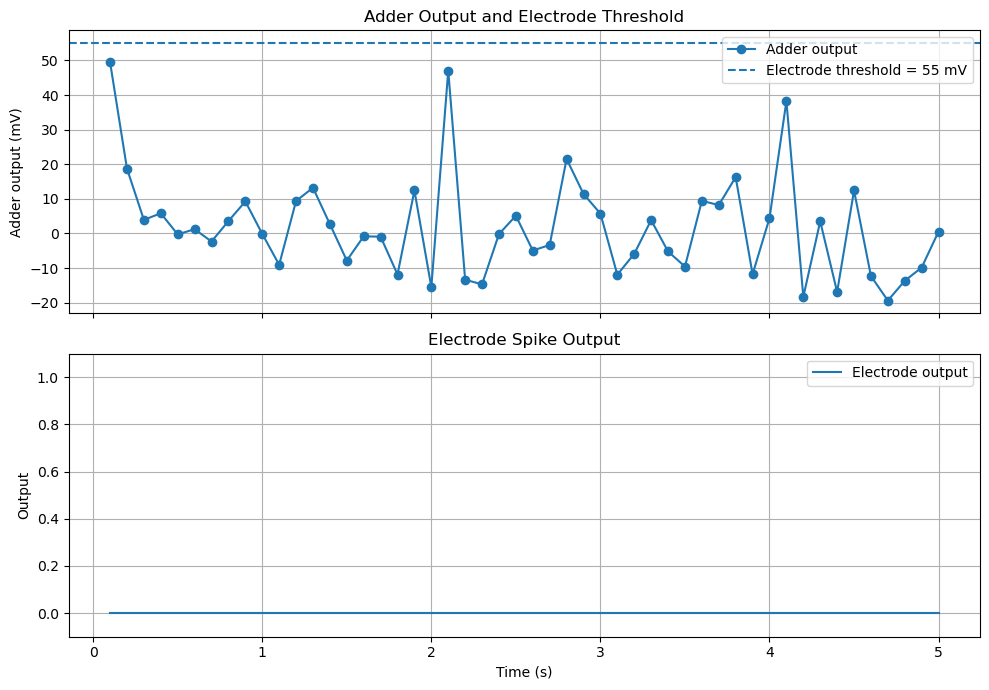

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load the log
# -----------------------------
df = pd.read_csv("../bin/top_threshold_55_log.csv", sep=";", skiprows=1)
df["time"] = df["time"].astype(float)

# -----------------------------
# Extract adder outputs
# -----------------------------
df_adder = df[
    (df["model_name"] == "adder") &
    (df["port_name"] == "sum_out")
].copy()

df_adder["sum_out"] = pd.to_numeric(df_adder["data"], errors="coerce")

# -----------------------------
# Extract electrode outputs
# -----------------------------
df_elec_out = df[
    (df["model_name"] == "electrode") &
    (df["port_name"] == "spike_out")
].copy()

df_elec_out["spike"] = pd.to_numeric(df_elec_out["data"], errors="coerce")

# -----------------------------
# Extract electrode threshold from state rows
# -----------------------------
df_elec_state = df[
    (df["model_name"] == "electrode") &
    (df["port_name"].isna() | (df["port_name"] == ""))
].copy()

df_elec_state["threshold"] = (
    df_elec_state["data"]
    .str.extract(r"threshold:\s*(-?\d+\.?\d*)")[0]
    .astype(float)
)

threshold = df_elec_state["threshold"].iloc[0]

# -----------------------------
# Build full plotting grid for electrode outputs
# using adder output times
# -----------------------------
df_plot_elec = df_adder[["time"]].copy()
df_plot_elec = df_plot_elec.merge(
    df_elec_out[["time", "spike"]],
    on="time",
    how="left"
)
df_plot_elec["spike"] = df_plot_elec["spike"].fillna(0)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top subplot: adder output
axes[0].plot(df_adder["time"], df_adder["sum_out"], marker="o", label="Adder output")
axes[0].axhline(
    y=threshold,
    linestyle="--",
    label=f"Electrode threshold = {threshold:.0f} mV"
)
axes[0].set_ylabel("Adder output (mV)")
axes[0].set_title("Adder Output and Electrode Threshold")
axes[0].grid(True)
axes[0].legend()

# Bottom subplot: electrode output
axes[1].step(df_plot_elec["time"], df_plot_elec["spike"], where="post", label="Electrode output")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Output")
axes[1].set_title("Electrode Spike Output")
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
#plt.savefig("top_threshold_55_plots.png", dpi=300, bbox_inches="tight")
plt.show()

## Analysis of electrode_brain_sim_log.csv

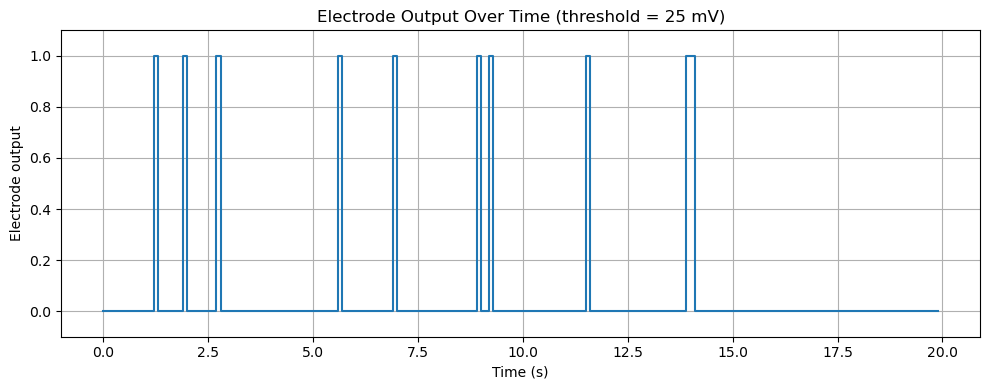

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load the log
# -----------------------------
df = pd.read_csv("../bin/electrode_brain_log.csv", sep=";", skiprows=1)
df["time"] = df["time"].astype(float)

# -----------------------------
# Extract electrode threshold
# -----------------------------
df_state = df[
    (df["model_name"] == "electrode") &
    (df["port_name"].isna() | (df["port_name"] == ""))
].copy()

df_state["threshold"] = (
    df_state["data"]
    .str.extract(r"threshold:\s*(-?\d+\.?\d*)")[0]
    .astype(float)
)

threshold = df_state["threshold"].iloc[0]

# -----------------------------
# Extract electrode spike outputs
# -----------------------------
df_out = df[
    (df["model_name"] == "electrode") &
    (df["port_name"] == "spike_out")
].copy()

df_out["spike"] = pd.to_numeric(df_out["data"], errors="coerce")

# -----------------------------
# Build time grid from all timestamps
# -----------------------------
times = pd.DataFrame({"time": sorted(df["time"].unique())})

df_plot = times.merge(
    df_out[["time","spike"]],
    on="time",
    how="left"
)

df_plot["spike"] = df_plot["spike"].fillna(0)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,4))

plt.step(df_plot["time"], df_plot["spike"], where="post")

plt.xlabel("Time (s)")
plt.ylabel("Electrode output")
plt.title(f"Electrode Output Over Time (threshold = {threshold:.0f} mV)")

plt.ylim(-0.1,1.1)
plt.grid(True)

plt.tight_layout()
#plt.savefig("electrode_brain_output.png", dpi=300, bbox_inches="tight")
plt.show()